# Analiza logów - notebook prezentacyjny
Notebook pokazuje pipeline: raw logs -> parser -> AnalysisConfig -> argparse -> analyze_log_file() -> AnalysisResult -> statistics -> visualization -> OpenMP -> MPI -> CUDA (future).


## 0) Importy i ustawienia


In [1]:
from datetime import datetime
from pathlib import Path
import subprocess
import sys
import json

from IPython.display import Image, display

from config import DEFAULT_INPUT_LOG, DEFAULT_LEVELS, DEFAULT_PHRASES, REPORTS_DIR
from domain.models import AnalysisConfig
from processing.analyzer import analyze_log_file
from processing.statistics import total_parsed_ratio, total_matched_ratio, top_error_hours
from report import result_to_dict, save_report_json, save_filtered_lines_csv
from visualization.plots import plot_errors_per_hour


In [2]:
INPUT_LOG = str(DEFAULT_INPUT_LOG)
REPORTS = Path("reports")
PLOTS = REPORTS / "plots"
REPORTS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
INPUT_LOG


'C:\\pycharm_pro_projects\\prir_projekt\\data\\raw\\Hadoop_200k.log'

## 1) Parsing i pipeline
Wejście surowe logi -> parser (`analyze_log_file`) -> `AnalysisResult`.


In [3]:
config_preview = AnalysisConfig.from_iterables(
    phrases=DEFAULT_PHRASES,
    levels=DEFAULT_LEVELS,
)
result_preview = analyze_log_file(INPUT_LOG, config_preview)
report_preview = result_to_dict(result_preview)
report_preview["summary"]


{'total_lines': 200000,
 'parsed_lines': 200000,
 'parse_errors': 0,
 'matched_lines': 200000}

In [4]:
print("Przykładowe linie dopasowane przez aktualny filtr (pierwsze 5):")
for line in result_preview.filtered_lines[:5]:
    print(line)


Przykładowe linie dopasowane przez aktualny filtr (pierwsze 5):
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high
2015-10-01 00:03:25,000 INFO [main] AsyncDispatcher: FATAL application crashed


In [5]:
date_min = None
date_max = None
if result_preview.filtered_lines:
    # tylko podgląd tekstowy; zakres dat kontrolujemy przez CLI
    pass
{"pipeline": "raw logs -> AnalysisConfig -> analyze_log_file -> AnalysisResult"}


{'pipeline': 'raw logs -> AnalysisConfig -> analyze_log_file -> AnalysisResult'}

## 2) Konfiguracja analizy (AnalysisConfig)
Argumenty: `phrases`, `levels`, `date_from`, `date_to`, `error_type`, `limit`.


In [6]:
config = AnalysisConfig.from_iterables(
    phrases=DEFAULT_PHRASES,
    levels=DEFAULT_LEVELS,
)
config


AnalysisConfig(phrases=('ERROR', 'WARNING', 'INFO'), levels=(), error_type='ERROR', limit=None, date_from=None, date_to=None)

## 3) Główna analiza
Opis: `analyze_log_file(file_path, config)`


In [7]:
result = analyze_log_file(INPUT_LOG, config)
report = result_to_dict(result)
report["summary"]


{'total_lines': 200000,
 'parsed_lines': 200000,
 'parse_errors': 0,
 'matched_lines': 200000}

## 4) Phrase analysis przez CLI (`--phrase`)


In [8]:
commands = [
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "ERROR", "--limit", "10"],
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "WARNING", "--limit", "10"],
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "INFO", "--limit", "10"],
]
for cmd in commands:
    print("\n$", " ".join(cmd))
    completed = subprocess.run(cmd, capture_output=True, text=True)
    print(completed.stdout[:2500])
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError("CLI phrase command failed")



$ C:\pycharm_pro_projects\prir_projekt\.venv\Scripts\python.exe main.py --input C:\pycharm_pro_projects\prir_projekt\data\raw\Hadoop_200k.log --phrase ERROR --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 99808
INFO: 33217

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high
2015-10-01 00:03:25,000 IN

## 5) Wyodrębnianie wierszy spełniających kryteria
Przykłady: tylko poziom `ERROR`, tylko zakres dat.


In [9]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--filter-level", "ERROR",
    "--show-level-counts",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI filter-level command failed")


$ C:\pycharm_pro_projects\prir_projekt\.venv\Scripts\python.exe main.py --input C:\pycharm_pro_projects\prir_projekt\data\raw\Hadoop_200k.log --filter-level ERROR --show-level-counts --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904
INFO: 33217

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:19:49,000 ERROR [main] JobHistoryUtils: Registering dispatcher
2015-10-01 00:24:49,000 ERROR [main] AsyncDispatcher: Container allocation successful
2015-10-01 00:28:58,000 ERROR [main] Speculator: ERROR failed to allocate con

In [10]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--start-date", "2023-01-01",
    "--end-date", "2023-12-31",
    "--show-level-counts",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI date-range command failed")


$ C:\pycharm_pro_projects\prir_projekt\.venv\Scripts\python.exe main.py --input C:\pycharm_pro_projects\prir_projekt\data\raw\Hadoop_200k.log --start-date 2023-01-01 --end-date 2023-12-31 --show-level-counts --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904
INFO: 33217

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
Matched lines: 0

=== LEVEL COUNTS (CLI VIEW) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092



### 5.2) Eksport wyodrębnionych wierszy


In [11]:
filtered_csv = REPORTS / "filtered_error_lines.csv"
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--filter-level", "ERROR",
    "--output-filtered-csv", str(filtered_csv),
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:2000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI filtered csv export failed")
filtered_csv


$ C:\pycharm_pro_projects\prir_projekt\.venv\Scripts\python.exe main.py --input C:\pycharm_pro_projects\prir_projekt\data\raw\Hadoop_200k.log --filter-level ERROR --output-filtered-csv reports\filtered_error_lines.csv

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904
INFO: 33217

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6
2015-10-01 10:00 -> 8
2015-10-01 11:00 -> 7
2015-10-01 12:00 -> 10
2015-10-01 13:00 -> 9
2015-10-01 14:00 -> 6
2015-10-01 15:00 -> 11
2015-10-01 16:00 -> 9
2015-10-01 17:00 -> 5
2015-10-01 18:00 -> 10
2015-10-01 19:00 -> 11
2015-10-01 20:00 -> 8
2015-10-01 21:00 -> 10
2015-10-01 22:00 -> 7
2015-10-01 23:00 -> 7
2015-10-02 00:

WindowsPath('reports/filtered_error_lines.csv')

In [12]:
print("Wyodrębnione wiersze są zapisane w:", filtered_csv)


Wyodrębnione wiersze są zapisane w: reports\filtered_error_lines.csv


### 5.3) Filtrowanie po frazie przez CLI


In [13]:
cmd = [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "ERROR", "--limit", "10"]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:2500])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI phrase filter command failed")


$ C:\pycharm_pro_projects\prir_projekt\.venv\Scripts\python.exe main.py --input C:\pycharm_pro_projects\prir_projekt\data\raw\Hadoop_200k.log --phrase ERROR --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 99808
INFO: 33217

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high
2015-10-01 00:03:25,000 INF

## 6) Statystyki zdarzeń w czasie
Przykład: liczba zdarzeń na godzinę (`--show-errors-per-hour`, `--error-type`, `--top-error-hours`, `--limit`).


In [14]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--show-errors-per-hour",
    "--error-type", "ERROR",
    "--top-error-hours", "10",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI errors-per-hour command failed")


$ C:\pycharm_pro_projects\prir_projekt\.venv\Scripts\python.exe main.py --input C:\pycharm_pro_projects\prir_projekt\data\raw\Hadoop_200k.log --show-errors-per-hour --error-type ERROR --top-error-hours 10 --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904
INFO: 33217

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNI

In [15]:
result = analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(error_type="ERROR"))
result.errors_per_hour


{'2015-10-01 00:00': 7,
 '2015-10-01 01:00': 7,
 '2015-10-01 02:00': 5,
 '2015-10-01 03:00': 8,
 '2015-10-01 04:00': 10,
 '2015-10-01 05:00': 4,
 '2015-10-01 06:00': 9,
 '2015-10-01 07:00': 7,
 '2015-10-01 08:00': 3,
 '2015-10-01 09:00': 6,
 '2015-10-01 10:00': 8,
 '2015-10-01 11:00': 7,
 '2015-10-01 12:00': 10,
 '2015-10-01 13:00': 9,
 '2015-10-01 14:00': 6,
 '2015-10-01 15:00': 11,
 '2015-10-01 16:00': 9,
 '2015-10-01 17:00': 5,
 '2015-10-01 18:00': 10,
 '2015-10-01 19:00': 11,
 '2015-10-01 20:00': 8,
 '2015-10-01 21:00': 10,
 '2015-10-01 22:00': 7,
 '2015-10-01 23:00': 7,
 '2015-10-02 00:00': 5,
 '2015-10-02 01:00': 11,
 '2015-10-02 02:00': 5,
 '2015-10-02 03:00': 7,
 '2015-10-02 04:00': 8,
 '2015-10-02 05:00': 5,
 '2015-10-02 06:00': 8,
 '2015-10-02 07:00': 4,
 '2015-10-02 08:00': 12,
 '2015-10-02 09:00': 4,
 '2015-10-02 10:00': 5,
 '2015-10-02 11:00': 7,
 '2015-10-02 12:00': 6,
 '2015-10-02 13:00': 7,
 '2015-10-02 14:00': 7,
 '2015-10-02 15:00': 2,
 '2015-10-02 16:00': 9,
 '2015-1

In [16]:
{
    "parsed_ratio": round(total_parsed_ratio(result), 4),
    "matched_ratio": round(total_matched_ratio(result), 4),
    "top_error_hours": top_error_hours(result, top_n=10),
}


{'parsed_ratio': 1.0,
 'matched_ratio': 1.0,
 'top_error_hours': [('2015-12-25 20:00', 17),
  ('2016-01-05 11:00', 17),
  ('2015-10-08 16:00', 16),
  ('2015-11-03 02:00', 16),
  ('2015-11-04 18:00', 16),
  ('2015-11-14 22:00', 16),
  ('2015-10-07 10:00', 15),
  ('2015-11-24 12:00', 15),
  ('2015-12-15 03:00', 15),
  ('2015-12-18 21:00', 15)]}

## 7) Visualization


## 8) Eksport wyników (AnalysisResult)


In [17]:
json_path = REPORTS / "notebook_report.json"
csv_path = REPORTS / "notebook_filtered.csv"
save_report_json(result, str(json_path))
save_filtered_lines_csv(result, str(csv_path))
json_path, csv_path


(WindowsPath('reports/notebook_report.json'),
 WindowsPath('reports/notebook_filtered.csv'))

## 9) OpenMP benchmark + wykresy


In [18]:
cmd = [sys.executable, 'openmp_speedup.py', '--input', INPUT_LOG, '--save-dir', str(REPORTS)]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('OpenMP benchmark failed')


   threads      time   speedup  efficiency
0        1  0.415718  1.000000    1.000000
1        2  0.435632  0.954287    0.477144
2        4  0.444298  0.935674    0.233919
3        8  0.443444  0.937475    0.117184
Figure(1200x400)



In [19]:
import csv
openmp_rows = []
with open(REPORTS / "benchmark_openmp.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        if i >= 10:
            break
        openmp_rows.append(row)
openmp_rows


[{'threads': '1',
  'time': '0.4157178000004933',
  'speedup': '1.0',
  'efficiency': '1.0'},
 {'threads': '2',
  'time': '0.4356318000009196',
  'speedup': '0.9542870837244106',
  'efficiency': '0.4771435418622053'},
 {'threads': '4',
  'time': '0.4442975000001752',
  'speedup': '0.9356744073516717',
  'efficiency': '0.23391860183791793'},
 {'threads': '8',
  'time': '0.44344400000045425',
  'speedup': '0.9374753069160198',
  'efficiency': '0.11718441336450247'}]

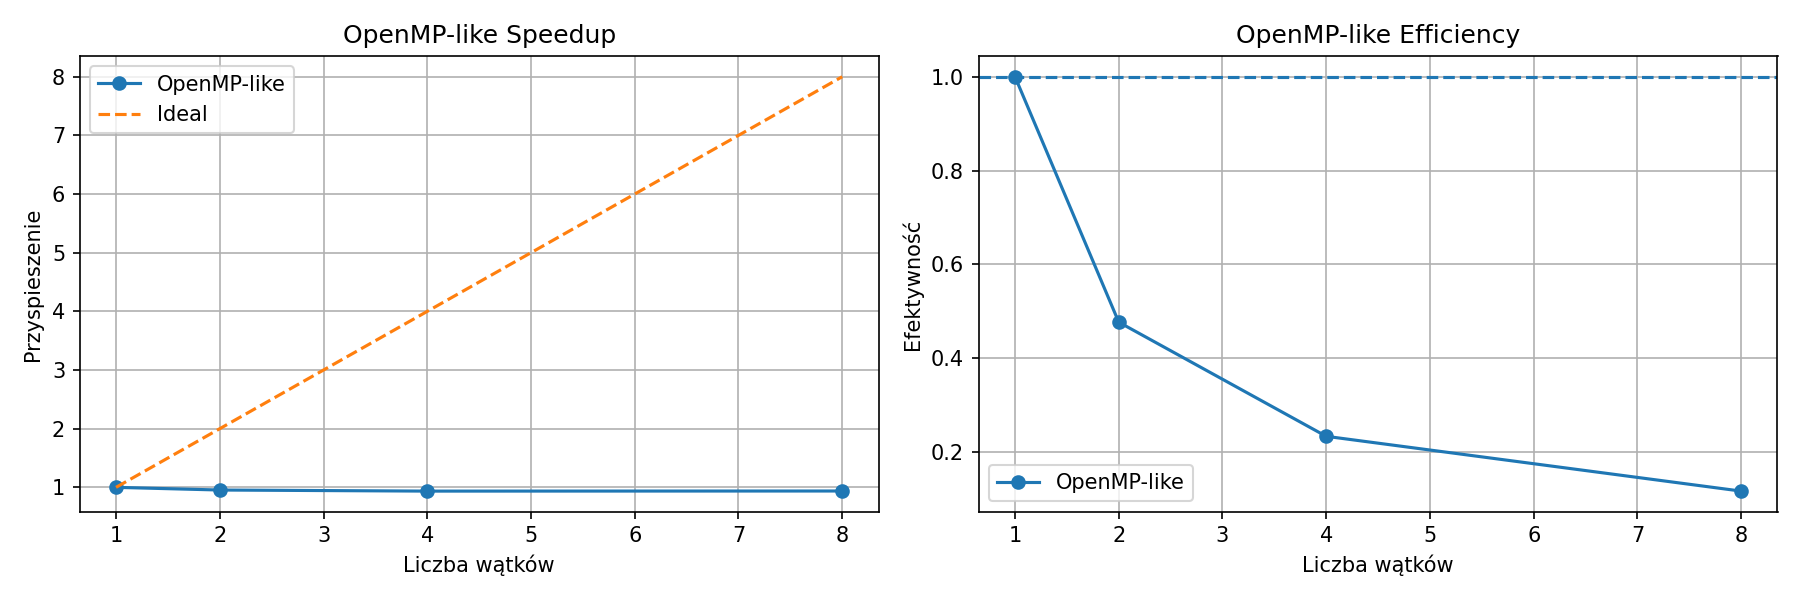

In [20]:
display(Image(filename=str(PLOTS / 'openmp_speedup_efficiency.png')))


## 10) MPI benchmark + wykresy


In [21]:
cmd = [sys.executable, 'mpi_speedup.py', '--input', INPUT_LOG, '--save-dir', str(REPORTS)]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('MPI benchmark failed (sprawdź instalację mpiexec / MPI).')


   processes      time   speedup  efficiency
0          1  0.256644  1.000000    1.000000
1          2  0.233243  1.100330    0.550165
2          4  0.314264  0.816652    0.204163
3          8  0.469203  0.546979    0.068372
Figure(1200x400)



In [22]:
import csv
mpi_rows = []
with open(REPORTS / "benchmark_mpi.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        if i >= 10:
            break
        mpi_rows.append(row)
mpi_rows


[{'processes': '1',
  'time': '0.2566443999985495',
  'speedup': '1.0',
  'efficiency': '1.0'},
 {'processes': '2',
  'time': '0.2332432000002882',
  'speedup': '1.1003296130315154',
  'efficiency': '0.5501648065157577'},
 {'processes': '4',
  'time': '0.314264099999491',
  'speedup': '0.8166519815625303',
  'efficiency': '0.20416299539063257'},
 {'processes': '8',
  'time': '0.4692032000002655',
  'speedup': '0.5469792192346605',
  'efficiency': '0.06837240240433257'}]

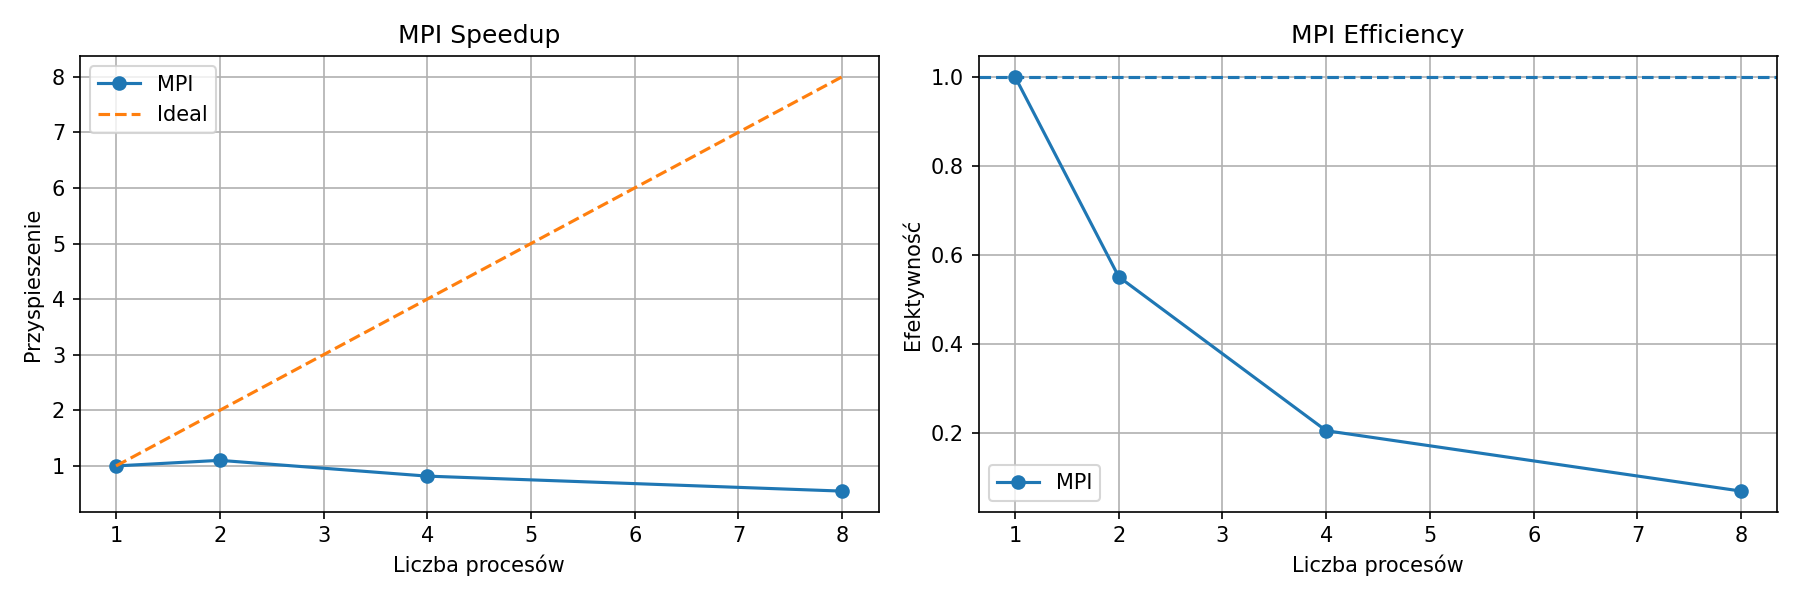

In [23]:
display(Image(filename=str(PLOTS / 'mpi_speedup_efficiency.png')))


## 11) Porównanie wydajności: sekwencyjnie vs OpenMP-like vs MPI
Poniżej wykres czasu wykonania i speedup względem trybu sekwencyjnego (1 worker/process).


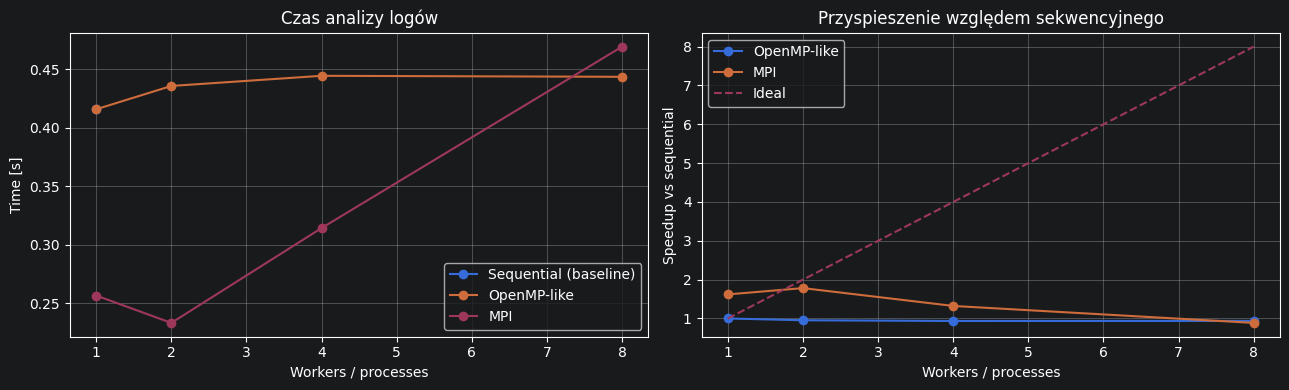

{'sequential_time_s': 0.415718,
 'best_openmp_time_s': 0.415718,
 'best_mpi_time_s': 0.233243}

In [24]:
import csv
import matplotlib.pyplot as plt

openmp_path = REPORTS / "benchmark_openmp.csv"
mpi_path = REPORTS / "benchmark_mpi.csv"

openmp_rows = []
with open(openmp_path, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        openmp_rows.append({"units": int(row["threads"]), "time": float(row["time"])})

mpi_rows = []
with open(mpi_path, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        mpi_rows.append({"units": int(row["processes"]), "time": float(row["time"])})

openmp_rows.sort(key=lambda r: r["units"])
mpi_rows.sort(key=lambda r: r["units"])

seq_candidates = [r["time"] for r in openmp_rows if r["units"] == 1] + [r["time"] for r in mpi_rows if r["units"] == 1]
if not seq_candidates:
    raise RuntimeError("Brak pomiaru sekwencyjnego (1). Uruchom benchmarki dla 1 worker/process.")
seq_time = seq_candidates[0]

openmp_speedup = [(r["units"], seq_time / r["time"]) for r in openmp_rows]
mpi_speedup = [(r["units"], seq_time / r["time"]) for r in mpi_rows]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot([1], [seq_time], marker="o", label="Sequential (baseline)")
ax[0].plot([r["units"] for r in openmp_rows], [r["time"] for r in openmp_rows], marker="o", label="OpenMP-like")
ax[0].plot([r["units"] for r in mpi_rows], [r["time"] for r in mpi_rows], marker="o", label="MPI")
ax[0].set_xlabel("Workers / processes")
ax[0].set_ylabel("Time [s]")
ax[0].set_title("Czas analizy logów")
ax[0].grid(True)
ax[0].legend()

ax[1].plot([u for u, _ in openmp_speedup], [s for _, s in openmp_speedup], marker="o", label="OpenMP-like")
ax[1].plot([u for u, _ in mpi_speedup], [s for _, s in mpi_speedup], marker="o", label="MPI")
max_units = max([u for u, _ in openmp_speedup] + [u for u, _ in mpi_speedup])
ax[1].plot(list(range(1, max_units + 1)), list(range(1, max_units + 1)), linestyle="--", label="Ideal")
ax[1].set_xlabel("Workers / processes")
ax[1].set_ylabel("Speedup vs sequential")
ax[1].set_title("Przyspieszenie względem sekwencyjnego")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

{
    "sequential_time_s": round(seq_time, 6),
    "best_openmp_time_s": round(min(r["time"] for r in openmp_rows), 6),
    "best_mpi_time_s": round(min(r["time"] for r in mpi_rows), 6),
}
